In [ ]:
import sklearn
from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch import nn

In [ ]:
# Create data
n_samples = 1000
X,y = make_circles(n_samples,
                   noise=0.03,
                   random_state=42)
print(f"First 5 samples: {X[1:5,:]}")

First 5 samples: [[-0.75615888  0.15325888]
 [-0.81539193  0.17328203]
 [-0.39373073  0.69288277]
 [ 0.44220765 -0.89672343]]


In [ ]:
circles = pd.DataFrame({"x1" : X[:,0],
                        "x2" : X[:,1],
                        "label" : y})

circles.head(10)

,x1,x2,label
0,0.754246,0.231481,1
1,-0.756159,0.153259,1
2,-0.815392,0.173282,1
3,-0.393731,0.692883,1
4,0.442208,-0.896723,0
5,-0.479646,0.676435,1
6,-0.013648,0.803349,1
7,0.771513,0.147760,1
8,-0.169322,-0.793456,1
9,-0.121486,1.021509,0


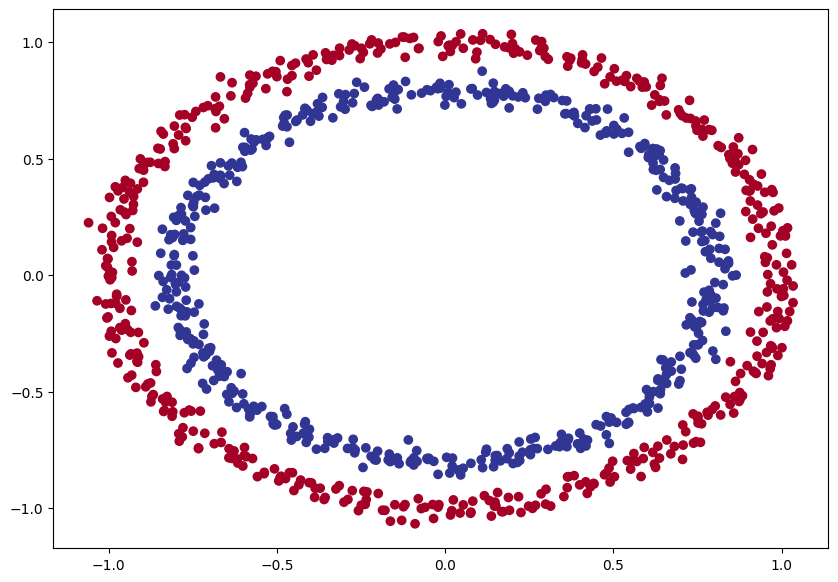

In [ ]:
plt.figure(figsize=[10,7])
plt.scatter(x=X[:,0],
            y=X[:,1],
            c=y,
            cmap=plt.cm.RdYlBu)


# 1) Preparing Data

## 1.1 Check Input and Output Shape

In [ ]:
# Check the data shape
X.shape,y.shape

((1000, 2), (1000,))

In [ ]:
X,y

(array([[ 0.75424625,  0.23148074],
        [-0.75615888,  0.15325888],
        [-0.81539193,  0.17328203],
        ...,
        [-0.13690036, -0.81001183],
        [ 0.67036156, -0.76750154],
        [ 0.28105665,  0.96382443]]),
 array([1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0,
        0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1,
        0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1,
        1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1,
        1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1,
        1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1,
        0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0,
        1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0,
        0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0,
        1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1,
        0, 1, 1, 0, 1, 0, 1, 

In [ ]:
# View the first sample
X_sample = X[0]
y_sample = y[0]

print(f"The first sample of X: {X_sample}")
print(f"The first sample of y: {y_sample}")
print(f"Shape of the first sample of X: {X_sample.shape}")

The first sample of X: [0.75424625 0.23148074]
The first sample of y: 1
Shape of the first sample of X: (2,)


## 1.2 Split for Training and Testing

In [ ]:
# Check the type of the data
print(f"The type of X and y are {type(X)} and {type(y)}")

# Convert data into torch.tensor
X_tensor = torch.from_numpy(X).type(torch.float)
y_tensor = torch.from_numpy(y).type(torch.float)

X_tensor,y_tensor

The type of X and y are <class 'numpy.ndarray'> and <class 'numpy.ndarray'>


(tensor([[ 0.7542,  0.2315],
         [-0.7562,  0.1533],
         [-0.8154,  0.1733],
         ...,
         [-0.1369, -0.8100],
         [ 0.6704, -0.7675],
         [ 0.2811,  0.9638]]),
 tensor([1., 1., 1., 1., 0., 1., 1., 1., 1., 0., 1., 0., 1., 1., 1., 1., 0., 1.,
         1., 0., 1., 0., 0., 1., 0., 0., 0., 1., 1., 1., 0., 0., 1., 0., 0., 0.,
         1., 1., 1., 0., 0., 0., 0., 1., 0., 0., 1., 1., 0., 1., 1., 1., 0., 1.,
         0., 0., 1., 0., 0., 1., 0., 0., 1., 0., 1., 1., 1., 1., 0., 1., 0., 0.,
         1., 1., 0., 0., 1., 0., 1., 0., 1., 0., 0., 0., 0., 1., 1., 1., 1., 0.,
         0., 0., 1., 0., 1., 0., 1., 0., 0., 1., 1., 0., 1., 0., 1., 1., 1., 1.,
         0., 1., 1., 1., 1., 1., 0., 0., 0., 1., 1., 0., 1., 0., 1., 0., 0., 1.,
         1., 0., 1., 1., 1., 1., 0., 1., 1., 0., 0., 0., 0., 0., 0., 0., 1., 0.,
         1., 1., 1., 0., 1., 0., 1., 0., 1., 0., 1., 0., 0., 1., 0., 1., 1., 1.,
         1., 1., 1., 1., 0., 1., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 1., 1.,


In [ ]:
# Split data into training and test sets
X_train,X_test,y_train,y_test = train_test_split(X,y,
                                                 test_size=0.2, # Percentage of the test data
                                                 random_state=42)

In [ ]:
len(X_train),len(X_test),len(y_train),len(y_test)

(800, 200, 800, 200)

In [ ]:
type(X_train),type(X_test),type(y_train),type(y_test)

(numpy.ndarray, numpy.ndarray, numpy.ndarray, numpy.ndarray)

## 1.3 Convert to Tensor

In [ ]:
# Convert the training and test datasets into tensors
X_train_tensor = torch.from_numpy(X_train).type(torch.float)
X_test_tensor = torch.from_numpy(X_test).type(torch.float)
y_train_tensor = torch.from_numpy(y_train).type(torch.float)
y_test_tensor = torch.from_numpy(y_test).type(torch.float)

# 2) Build a Model
To classify the blue and red dots
To do so we will:
1. Setup agnostic for gpu
2. Construct a model
3. Define loss and optimizer
4. Construct a training and test loop


## 2.1 Agnostic device

In [ ]:
# Setup device agnostic
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cpu


## 2.2 Construct a model
Our model will:
1. Subclass `nn.Module`
2. Create 2 `nn.Linear` layers to handle the shape of our data

The `nn.Linear` layer is a layer that performs a linear transformation on the input

    y = W*x + b

So the parameters in this layer would be the weights and biases. The shape of our input will define the argument `in_features`, while `out_features` depends on how many output values we want to have after passing the input through this layer.

3. Define a `forward()` method
4.

In [ ]:
# Subclass nn.Module
class CircleModel(nn.Module):
  def __init__(self):
    super().__init__()
    # 2.Create 2 nn.Linear layers
    self.layer_1 = nn.Linear(in_features=2, # Size of the input sample
                             out_features=5) # Takes in 2 features and upscale to 5 features. Each out_feature here can be considered as a neuron that takes in the two in_features and output one out_feature.
                                             #So out_features=5 means this layer has 5 neurons, each output one feature value.
    self.layer_2 = nn.Linear(in_features=5,
                             out_features=1) # Takes in 5 features and output 1 features
    # 2. Create 2 linear layers using nn.Sequential
    # self.two_linear_layers = nn.Sequential(
    #     nn.Linear(in_features=2,out_features=5),
    #     nn.Linear(in_features=5,out_features=1)
    # )
  # 3.Define forwand()
  def forward(self,x):
    return self.layer_2(self.layer_1(x)) # x -> self.layer_1 -> self.layer_2 -> output
    # return self.two_linear_layers(x)

# Instantiate an instance of the model to the device
model_circle = CircleModel().to(device)
model_circle

CircleModel(
  (layer_1): Linear(in_features=2, out_features=5, bias=True)
  (layer_2): Linear(in_features=5, out_features=1, bias=True)
)

In [ ]:
# Check if the parameters of our model is on device
next(model_circle.parameters()).device

device(type='cpu')

In [ ]:
# Duplicate the above model using `nn.Sequential`
model_circle = nn.Sequential(
    nn.Linear(in_features=2,out_features=5),
    nn.Linear(in_features=5,out_features=1)
).to(device)

model_circle

Sequential(
  (0): Linear(in_features=2, out_features=5, bias=True)
  (1): Linear(in_features=5, out_features=1, bias=True)
)

In [ ]:
model_circle.state_dict()

OrderedDict([('0.weight',
              tensor([[-0.0829, -0.2872],
                      [ 0.4691, -0.5582],
                      [-0.3260, -0.1997],
                      [-0.4252,  0.0667],
                      [-0.6984,  0.6386]])),
             ('0.bias', tensor([-0.6007,  0.5459,  0.1177, -0.2296,  0.4370])),
             ('1.weight',
              tensor([[ 0.0697,  0.3613,  0.0489, -0.1410,  0.1202]])),
             ('1.bias', tensor([-0.1213]))])

In [ ]:
# Make predictions
with torch.inference_mode():
  pred_untrained = model_circle(X_test_tensor.to(device))

print(f"Length of predictions: {len(pred_untrained)}, Shape: {pred_untrained.shape}")
print(f"Length of test sample: {len(X_test_tensor)}, Shape: {X_test_tensor.shape}")
print(f"\nFirst 10 predictions: \n{torch.round(pred_untrained[:10])}")
print(f"\nFirst 10 labels: \n{y_test_tensor[:10]}")

Length of predictions: 200, Shape: torch.Size([200, 1])
Length of test sample: 200, Shape: torch.Size([200, 2])

First 10 predictions: 
tensor([[-0.],
        [-0.],
        [0.],
        [-0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [-0.]])

First 10 labels: 
tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.])


## 2.3 Setup Loss Function and Optimizer
Which loss function and optimizer should you use?

For example for regression, you might want MAE or MSE

For classification, you might want to use cross entropy

And for optimizers, the two most common are SGD and ADAM

In [ ]:
# Setup loss fn
loss_fn = nn.BCEWithLogitsLoss() # <=> BCE with a built-in sigmoid activation, which activates the inputs before passing through BCE
# Setup optimizer
optimizer = torch.optim.Adam(params=model_circle.parameters(),
                             lr=0.1)

In [ ]:
# Calculate the accuracy
def accuracy_fn(y_true,y_pred):
  TP = torch.eq(y_true,y_pred).sum().item() # .item() -> single value
  acc = (TP/len(y_pred))*100
  return acc


# 3. Train Model
Traing loop:
1. Forward pass
2. Loss
3. Zero grad
4. Backpropagate
5. Gradient descent

## 3.1 Going from raw logit -> prediction probabilites -> prediction labels
Our model outputs raw logit

We can convert these **logits** into **prediction probabilities** by passing them to some kind of activation function

Then we can convert our model's prediction probabilities to **prediction labels** by either rounding them or taking the argmax()

In [ ]:
# View the first 5 outputs of the forward pass on the test dat
with torch.inference_mode():
  y_logits = model_circle(X_test_tensor.to(device)[:5])

y_logits

tensor([[-0.0338],
        [-0.0309],
        [ 0.0894],
        [-0.0692],
        [ 0.2967]])

In [ ]:
# Use sigmoid activation function on our model's logits to turn them into prediction probabilities
y_pred_prob = torch.sigmoid(y_logits)
y_pred_prob

tensor([[0.4916],
        [0.4923],
        [0.5223],
        [0.4827],
        [0.5736]])

For our prediction probability values, we need to perform a range-style rounding:
- `y_pred_prob` >= 0.5 -> y=1 (class 1)
- `y_pred_prob` < 0.5 -> y=0 (class 0)

In [ ]:
# Find the predicted labels
y_preds = torch.round(y_pred_prob)

# In full (logits - > pred prob -> pred labels)
y_pred_labels = torch.round(torch.sigmoid(model_circle(X_test_tensor.to(device)[:5])))

# Check for equality
print(torch.eq(y_test_tensor.to(device)[:5].squeeze(),y_pred_labels.squeeze()))

tensor([False,  True,  True,  True,  True])


## 3.2 Training loop

In [ ]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

# Initialize
epochs = 200
epoch_counts = []
training_loss_values = []
training_acc_values = []
test_loss_values = []
test_acc_values = []

# Put on to right device
X_train_tensor,y_train_tensor = X_train_tensor.to(device),y_train_tensor.to(device)
X_test_tensor,y_test_tensor = X_test_tensor.to(device),y_test_tensor.to(device)

for epoch in range(epochs):
  # Turn on training mode
  model_circle.train()

  # Forward
  y_logits = model_circle(X_train_tensor).squeeze()
  y_pred_labels = torch.round(torch.sigmoid(y_logits)) #

  # Training Loss
  ## loss = nn.BCELoss(torch.sigmoid(y_logits),y_train_tensor) # nn.BCELoss() expects prediction probabilities as input
  train_loss = loss_fn(y_logits,y_train_tensor) # nn.BCEwithLogitsLoss expects raw logits as input

  # Training accuracy
  acc_train = accuracy_fn(y_true=y_train_tensor,
              y_pred=y_pred_labels)

  # Reset gradient
  model_circle.zero_grad()

  # Backpropagate
  train_loss.backward()

  # Gradient descent
  optimizer.step()

  # Testing
  model_circle.eval()
  with torch.inference_mode():
    # Forward pass
    y_test_logits = model_circle(X_test_tensor).squeeze()
    y_test_labels = torch.round(torch.sigmoid(y_test_logits))
    # Test loss
    test_loss = loss_fn(y_test_logits,y_test_tensor)
    # Test accuracy
    acc_test = accuracy_fn(y_true=y_test_tensor,
                           y_pred=y_test_labels)

  if epoch % 20 == 0:
    epoch_counts.append(epoch)
    training_loss_values.append(train_loss)
    training_acc_values.append(acc_train)
    test_loss_values.append(test_loss)
    test_acc_values.append(acc_test)

    print(f"Epoc: {epoch} | Training Loss: {train_loss:.3f} | Training Accuracy: {acc_train:.2f} | Test Loss: {test_loss:.3f} | Test Accuracy: {acc_test:.2f}")


Epoc: 0 | Training Loss: 0.698 | Training Accuracy: 51.88 | Test Loss: 0.696 | Test Accuracy: 50.00
Epoc: 20 | Training Loss: 0.693 | Training Accuracy: 51.38 | Test Loss: 0.696 | Test Accuracy: 46.00
Epoc: 40 | Training Loss: 0.693 | Training Accuracy: 50.88 | Test Loss: 0.695 | Test Accuracy: 46.00
Epoc: 60 | Training Loss: 0.693 | Training Accuracy: 51.38 | Test Loss: 0.695 | Test Accuracy: 47.00
Epoc: 80 | Training Loss: 0.693 | Training Accuracy: 51.50 | Test Loss: 0.695 | Test Accuracy: 45.50
Epoc: 100 | Training Loss: 0.693 | Training Accuracy: 51.12 | Test Loss: 0.695 | Test Accuracy: 46.00
Epoc: 120 | Training Loss: 0.693 | Training Accuracy: 51.12 | Test Loss: 0.695 | Test Accuracy: 46.00
Epoc: 140 | Training Loss: 0.693 | Training Accuracy: 51.00 | Test Loss: 0.695 | Test Accuracy: 46.00
Epoc: 160 | Training Loss: 0.693 | Training Accuracy: 51.12 | Test Loss: 0.695 | Test Accuracy: 46.00
Epoc: 180 | Training Loss: 0.693 | Training Accuracy: 51.00 | Test Loss: 0.695 | Test Ac

# 4. Make predictions and evaluate the model

In [ ]:
import requests
from pathlib import Path

# Download helper functions from Learn PyTorch repo
if Path("helper_functions.py").is_file():
  print("helper_functions.py is already exists, skipping downloading")
else:
  print("Download helper_functions.py")
  request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/refs/heads/main/helper_functions.py")
  with open("helper_functions.py","wb") as f:
    f.write(request.content)



helper_functions.py is already exists, skipping downloading


In [ ]:
from helper_functions import plot_predictions, plot_decision_boundary

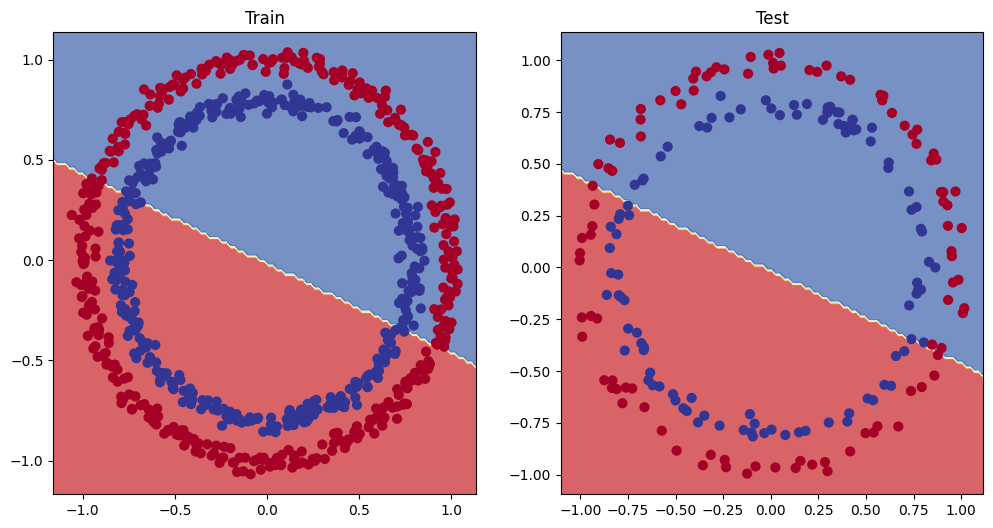

In [ ]:
plt.figure(figsize=[12,6])
plt.subplot(121)
plt.title("Train")
plot_decision_boundary(model_circle,X_train_tensor,y_train_tensor)
plt.subplot(122)
plt.title("Test")
plot_decision_boundary(model_circle,X_test_tensor,y_test_tensor)

The model produces a diagonal line to seperate/classify the data. This is why the accuracy of our model is always 50%

To fix this, we have to update our model so that it produces a circular line to classify the data

# 5. Improving a model (from a model perspective)

Common ways to improve a DL model:
- Add more layers -> Give the model more chances to learn about the pattern in the data
- Add more hidden units <=> more features in the hidden layers -> Similar reason as above
- Longer training time/ more epochs
- Changing the activation functions
- Change the learning rate
- Change the loss functions

These options deal directly with the model, rather than the data, hence model perspective

Let's try to improve the model by:
- Increase the number of hidden units: 5->10
- Increase the number of layers: 2->3
- Increase the number of epochs: 100->1000

## 5.1 Update our model

In [ ]:
class CircleModelV1(nn.Module):
  def __init__(self):
    super().__init__()
    self.layer_1 = nn.Linear(in_features=2,out_features=10)
    self.layer_2 = nn.Linear(in_features=10, out_features=10)
    self.layer_3 = nn.Linear(in_features=10,out_features=1)

  def forward(self,x):
    # z = self.layer_1(x)
    # z = self.layer_2(z)
    # z = self.layer_3(z)
    return self.layer_3(self.layer_2(self.layer_1(x)))

model_circleV1 = CircleModelV1().to(device)

model_circleV1



CircleModelV1(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=10, bias=True)
  (layer_3): Linear(in_features=10, out_features=1, bias=True)
)

## 5.2 Define Loss Function and Optimizer

In [ ]:
# Define loss function
loss_fn_V1 = nn.BCEWithLogitsLoss()

# Define optimizer
optimizer_V1 = torch.optim.SGD(params=model_circleV1.parameters(),
                               lr=0.1)



## 5.3 Training Loop

In [ ]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

# Initialize
epochs = 1000

# Put data on to the target device
X_train_tensor, y_train_tensor = X_train_tensor.to(device), y_train_tensor.to(device)
X_test_tensor, y_test_tensor = X_test_tensor.to(device), y_test_tensor.to(device)

for epoch in range(epochs):
  # Turn on training mode
  model_circleV1.train()

  # Forward pass
  pred_logits = model_circleV1(X_train_tensor).squeeze()
  pred_labels = torch.round(torch.sigmoid(pred_logits))

  # Calculate the loss
  train_loss = loss_fn_V1(pred_logits,y_train_tensor)

  # (Optional) Calculate the accuracy
  acc_train = accuracy_fn(y_true=y_train_tensor,y_pred=pred_labels)

  # Reset gradient
  optimizer_V1.zero_grad()

  # Backpropagation
  train_loss.backward()

  # Gradient descent
  optimizer_V1.step()

  # Testing
  model_circleV1.eval()
  with torch.inference_mode():
    # Forward pass:
    pred_test_logits = model_circleV1(X_test_tensor).squeeze()
    pred_test_labels = torch.round(torch.sigmoid(pred_test_logits))

    # Calculate the loss
    test_loss = loss_fn_V1(pred_test_logits,y_test_tensor)

    # Calculate the accuracy
    acc_test = accuracy_fn(y_true=y_test_tensor,y_pred=pred_test_labels)

  if epoch % 20 == 0:
    epoch_counts.append(epoch)
    training_loss_values.append(train_loss)
    training_acc_values.append(acc_train)
    test_loss_values.append(test_loss)
    test_acc_values.append(acc_test)

    print(f"Epoc: {epoch} | Training Loss: {train_loss:.3f} | Training Accuracy: {acc_train:.2f} | Test Loss: {test_loss:.3f} | Test Accuracy: {acc_test:.2f}")



Epoc: 0 | Training Loss: 0.694 | Training Accuracy: 50.88 | Test Loss: 0.693 | Test Accuracy: 51.00
Epoc: 20 | Training Loss: 0.694 | Training Accuracy: 50.12 | Test Loss: 0.693 | Test Accuracy: 49.50
Epoc: 40 | Training Loss: 0.693 | Training Accuracy: 50.38 | Test Loss: 0.693 | Test Accuracy: 49.00
Epoc: 60 | Training Loss: 0.693 | Training Accuracy: 49.38 | Test Loss: 0.693 | Test Accuracy: 51.50
Epoc: 80 | Training Loss: 0.693 | Training Accuracy: 50.12 | Test Loss: 0.694 | Test Accuracy: 50.00
Epoc: 100 | Training Loss: 0.693 | Training Accuracy: 50.38 | Test Loss: 0.694 | Test Accuracy: 48.00
Epoc: 120 | Training Loss: 0.693 | Training Accuracy: 50.75 | Test Loss: 0.694 | Test Accuracy: 46.50
Epoc: 140 | Training Loss: 0.693 | Training Accuracy: 51.00 | Test Loss: 0.694 | Test Accuracy: 48.00
Epoc: 160 | Training Loss: 0.693 | Training Accuracy: 51.12 | Test Loss: 0.694 | Test Accuracy: 47.00
Epoc: 180 | Training Loss: 0.693 | Training Accuracy: 51.12 | Test Loss: 0.694 | Test Ac

## 5.3 Evaluate the Model

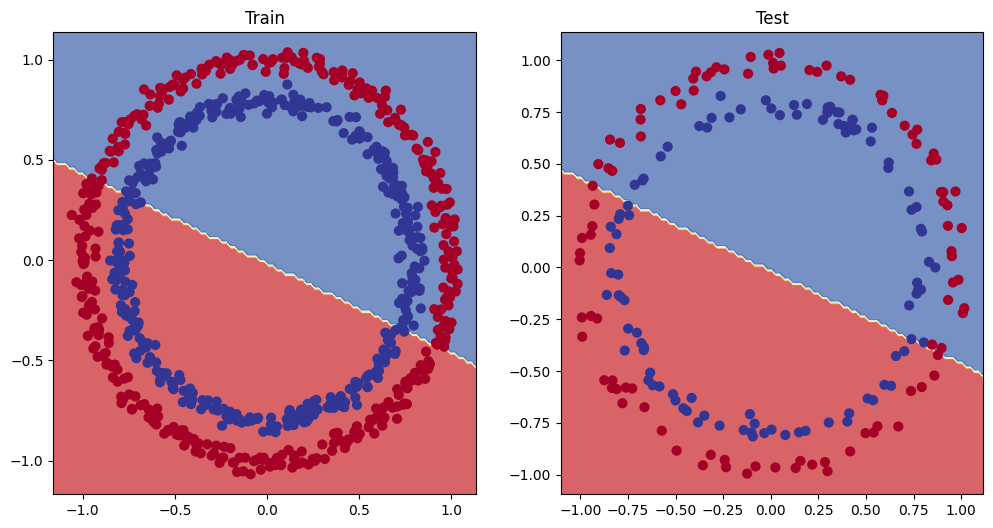

In [ ]:
plt.figure(figsize=[12,6])
plt.subplot(121)
plt.title("Train")
plot_decision_boundary(model_circleV1,X_train_tensor,y_train_tensor)
plt.subplot(122)
plt.title("Test")
plot_decision_boundary(model_circleV1,X_test_tensor,y_test_tensor)

Despite having changed the hyperparameters, our model isn't improved
Now let's test if our model can predict anything at all

## 5.4 Preparing data to see if our model can fit a straight line
One way to troubleshoot to a large problem is to test out a smaller problem


In [ ]:
# Creat some data
w = 0.7
b = 0.3
start = 0
end = 1
step = 0.01

# Create data
X_regression = torch.arange(start,end,step).unsqueeze(dim=1)
y_regression = w*X_regression + b

In [ ]:
# Create a training and test dataset
train_split = int(0.8*len(X_regression))

X_train_reg, y_train_reg = X_regression[:train_split], y_regression[:train_split]
X_test_reg, y_test_reg = X_regression[train_split:], y_regression[train_split:]

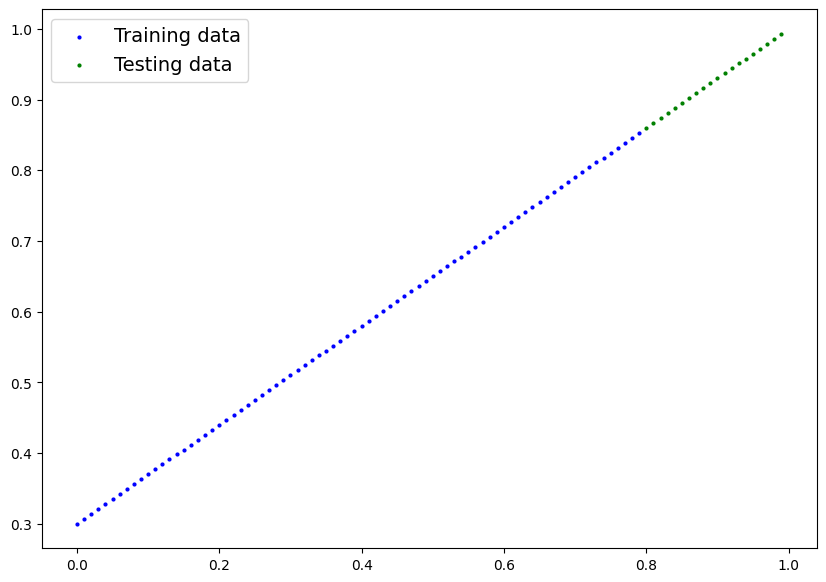

In [ ]:
plot_predictions(train_data=X_train_reg,train_labels=y_train_reg,test_data=X_test_reg,test_labels=y_test_reg)

### 5.4.1 Adjust the model to fit a straight line

In [ ]:
# Same architecture as model_circleV1 but diff. input size
model_2 = nn.Sequential(
    nn.Linear(in_features=1,out_features=10),
    nn.Linear(in_features=10,out_features=10),
    nn.Linear(in_features=10,out_features=1)
).to(device)

In [ ]:
# Loss and optimizer
loss_fn = nn.L1Loss()
optimizer = torch.optim.SGD(params=model_2.parameters(),
                            lr=0.01)

In [ ]:
# Train the model
torch.manual_seed(42)
torch.cuda.manual_seed(42)

# Nr of epochs
epochs = 2000

# Put data on target device
X_train_reg, y_train_reg = X_train_reg.to(device), y_train_reg.to(device)
X_test_reg, y_test_reg = X_test_reg.to(device), y_test_reg.to(device)

# Training loop
for epoch in range(epochs):
  # Turn on training mode
  model_2.train()

  # Forward
  y_pred = model_2(X_train_reg)

  # Compute loss
  train_loss = loss_fn(y_train_reg,y_pred)

  # Reset grad
  model_2.zero_grad()

  # Backpropagation
  train_loss.backward()

  # Grad. descent
  optimizer.step()

  # Testing
  model_2.eval()
  with torch.inference_mode():
    # Forward
    y_test_pred = model_2(X_test_reg)
    # Calculate loss
    test_loss = loss_fn(y_test_reg,y_test_pred)

    if epoch % 100 == 0:
    # epoch_counts.append(epoch)
    # training_loss_values.append(train_loss)
    # training_acc_values.append(acc_train)
    # test_loss_values.append(test_loss)
    # test_acc_values.append(acc_test)
      print(f"Epoc: {epoch} | Training Loss: {train_loss:.3f} | Test Loss: {test_loss:.3f}")





Epoc: 0 | Training Loss: 0.760 | Test Loss: 0.911
Epoc: 100 | Training Loss: 0.029 | Test Loss: 0.001
Epoc: 200 | Training Loss: 0.025 | Test Loss: 0.002
Epoc: 300 | Training Loss: 0.021 | Test Loss: 0.003
Epoc: 400 | Training Loss: 0.020 | Test Loss: 0.003
Epoc: 500 | Training Loss: 0.019 | Test Loss: 0.004
Epoc: 600 | Training Loss: 0.019 | Test Loss: 0.004
Epoc: 700 | Training Loss: 0.019 | Test Loss: 0.004
Epoc: 800 | Training Loss: 0.018 | Test Loss: 0.003
Epoc: 900 | Training Loss: 0.018 | Test Loss: 0.004
Epoc: 1000 | Training Loss: 0.018 | Test Loss: 0.003
Epoc: 1100 | Training Loss: 0.017 | Test Loss: 0.003
Epoc: 1200 | Training Loss: 0.016 | Test Loss: 0.003
Epoc: 1300 | Training Loss: 0.016 | Test Loss: 0.003
Epoc: 1400 | Training Loss: 0.016 | Test Loss: 0.003
Epoc: 1500 | Training Loss: 0.016 | Test Loss: 0.003
Epoc: 1600 | Training Loss: 0.016 | Test Loss: 0.003
Epoc: 1700 | Training Loss: 0.015 | Test Loss: 0.002
Epoc: 1800 | Training Loss: 0.015 | Test Loss: 0.003
Epoc:

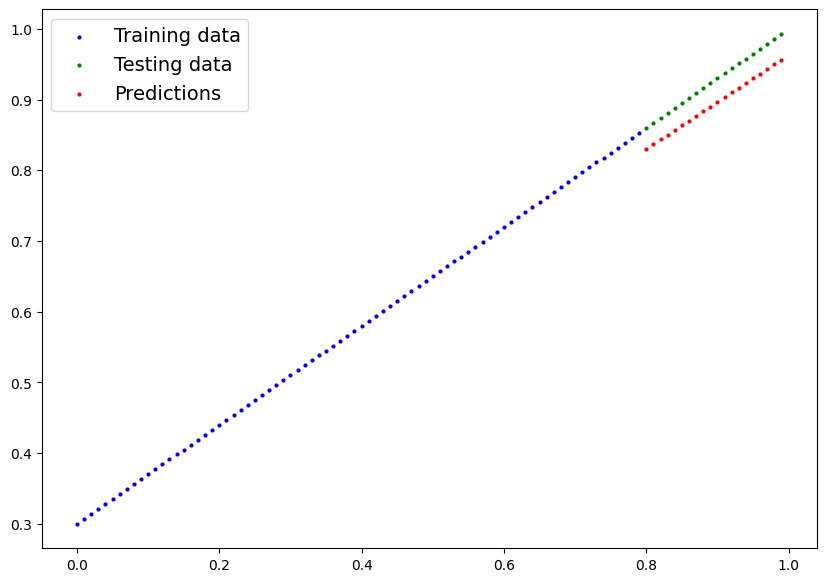

In [ ]:
# Evaluate
model_2.eval()
with torch.inference_mode():
  y_preds = model_2(X_test_reg)

plot_predictions(train_data=X_train_reg.cpu(),
                 train_labels=y_train_reg.cpu(),
                 test_data=X_test_reg.cpu(),
                 test_labels=y_test_reg.cpu(),
                 predictions=y_preds.cpu())

# 6. Non-linearity

## 6.1 Recreate the data

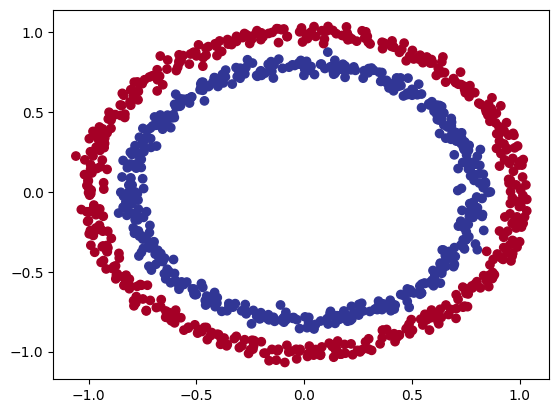

In [ ]:
# Make and plot data
n_samples = 1000

X,y = make_circles(n_samples=n_samples,
                   noise=0.03,
                   random_state=42)

plt.scatter(X[:,0],X[:,1],c=y,cmap=plt.cm.RdYlBu)

## 6.2 Split the data and Convert to tensor

In [ ]:
# Split
X_train,X_test,y_train,y_test = train_test_split(X,y,
                                                 test_size=0.2,
                                                 random_state=42)

X_train,y_train = torch.from_numpy(X_train).type(torch.float32), torch.from_numpy(y_train).type(torch.float32)
X_test,y_test = torch.from_numpy(X_test).type(torch.float32),torch.from_numpy(y_test).type(torch.float32)


In [ ]:
X_train[:5],y_train[:5],X_test[:5],y_test[:5]

(tensor([[ 0.6579, -0.4651],
         [ 0.6319, -0.7347],
         [-1.0086, -0.1240],
         [-0.9666, -0.2256],
         [-0.1666,  0.7994]]),
 tensor([1., 0., 0., 0., 1.]),
 tensor([[-0.3752,  0.6827],
         [ 0.0154,  0.9600],
         [-0.7028, -0.3147],
         [-0.2853,  0.9664],
         [ 0.4024, -0.7438]]),
 tensor([1., 0., 1., 0., 1.]))

## 6.3 Build a non-linear model

In [ ]:
# Build a model with non-linear activation function
class CircleModel_V2(nn.Module):
  def __init__(self):
    super().__init__()
    self.layer_1 = nn.Linear(in_features=2,out_features=10)
    self.layer_2 = nn.Linear(in_features=10,out_features=10)
    self.layer_3 = nn.Linear(in_features=10,out_features=1)

    self.relu = nn.ReLU()

  def forward(self,x):
    return self.layer_3(self.relu(self.layer_2(self.relu(self.layer_1(x)))))

model_3 = CircleModel_V2()

model_3

CircleModel_V2(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=10, bias=True)
  (layer_3): Linear(in_features=10, out_features=1, bias=True)
  (relu): ReLU()
)

## 6.4 Train Model

In [ ]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

# Initialize
epochs = 2000
epoch_counts = []
training_loss_values = []
training_acc_values = []
test_loss_values = []
test_acc_values = []

# Put the variable on device
X_train,y_train = X_train.to(device),y_train.to(device)
X_test,y_test = X_test.to(device),y_test.to(device)

# Setup loss function and optimizer
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(params=model_3.parameters(),
                            lr=0.1)




In [ ]:
# Training Loop
for epoch in range(epochs):
  # Turn on training mode
  model_3.train()

  # forward
  y_train_logits = model_3(X_train).squeeze()
  y_train_pred = torch.round(torch.sigmoid(y_train_logits))

  # Calculate the loss
  train_loss = loss_fn(y_train_logits,y_train)
  # Calculate the acc
  acc_train = accuracy_fn(y_true=y_train,y_pred=y_train_pred)

  # Set grad. zero
  model_3.zero_grad()

  #Backpropagate
  train_loss.backward()

  # Grad. descent
  optimizer.step()

  # Testing
  model_3.eval()
  with torch.inference_mode():
    # Forward
    y_test_logits = model_3(X_test).squeeze()
    y_test_pred = torch.round(torch.sigmoid(y_test_logits))

    # Calculate loss and acc
    test_loss = loss_fn(y_test_logits,y_test)
    acc_test = accuracy_fn(y_true=y_test,y_pred=y_test_pred)

    if epoch % 100 == 0:
      epoch_counts.append(epoch)
      training_loss_values.append(train_loss)
      training_acc_values.append(acc_train)
      test_loss_values.append(test_loss)
      test_acc_values.append(acc_test)

      print(f"Epoc: {epoch} | Training Loss: {train_loss:.3f} | Training Accuracy: {acc_train:.2f} | Test Loss: {test_loss:.3f} | Test Accuracy: {acc_test:.2f}")



Epoc: 0 | Training Loss: 0.693 | Training Accuracy: 50.00 | Test Loss: 0.693 | Test Accuracy: 50.00
Epoc: 100 | Training Loss: 0.691 | Training Accuracy: 52.88 | Test Loss: 0.691 | Test Accuracy: 52.50
Epoc: 200 | Training Loss: 0.690 | Training Accuracy: 53.37 | Test Loss: 0.689 | Test Accuracy: 55.00
Epoc: 300 | Training Loss: 0.688 | Training Accuracy: 53.00 | Test Loss: 0.687 | Test Accuracy: 56.00
Epoc: 400 | Training Loss: 0.685 | Training Accuracy: 52.75 | Test Loss: 0.684 | Test Accuracy: 56.50
Epoc: 500 | Training Loss: 0.681 | Training Accuracy: 52.75 | Test Loss: 0.679 | Test Accuracy: 56.50
Epoc: 600 | Training Loss: 0.675 | Training Accuracy: 54.50 | Test Loss: 0.673 | Test Accuracy: 56.00
Epoc: 700 | Training Loss: 0.667 | Training Accuracy: 58.38 | Test Loss: 0.663 | Test Accuracy: 59.00
Epoc: 800 | Training Loss: 0.652 | Training Accuracy: 64.00 | Test Loss: 0.648 | Test Accuracy: 67.50
Epoc: 900 | Training Loss: 0.624 | Training Accuracy: 74.00 | Test Loss: 0.621 | Tes

## 6.5 Evaluate Model

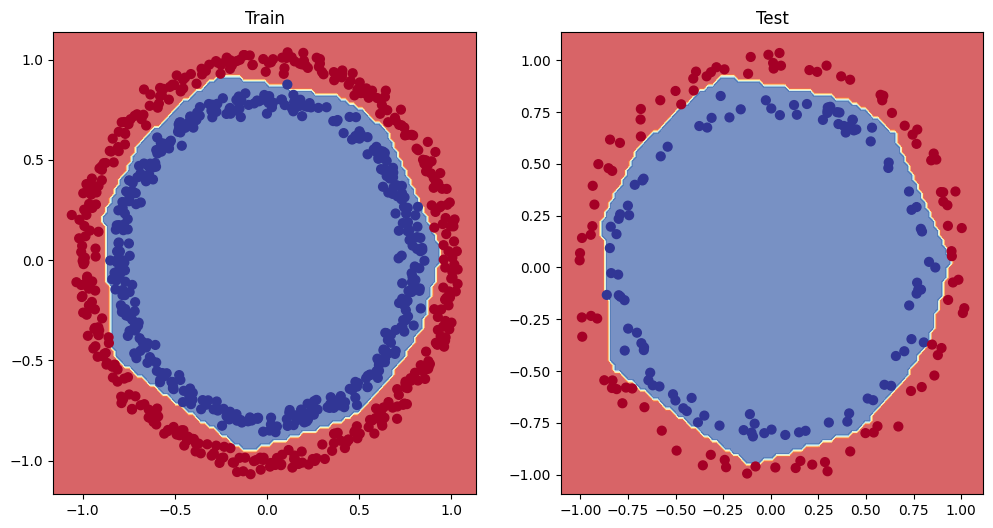

In [ ]:
plt.figure(figsize=[12,6])
plt.subplot(121)
plt.title("Train")
plot_decision_boundary(model_3,X_train,y_train)
plt.subplot(122)
plt.title("Test")
plot_decision_boundary(model_3,X_test,y_test)